In [1]:
import sys
import os
import libcontext

In [2]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns

In [3]:
from src.adagram import AdaGram
from src.adagram_project_splitting import AdaGramPS
from src.shampoo import Shampoo

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

learning_rates = [0.001, 0.01, 0.1]
num_epochs = 100

def generate_data(n_samples=100, dim=1, noise=0.1):
    X = torch.rand(n_samples, dim) * 10
    y = 2 * X + 1 + noise * torch.randn(n_samples, dim)
    return X, y

X, y = generate_data(n_samples=500, dim=10)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(10, 10)

    def forward(self, x):
        return self.linear(x)
    
class MultiClassLogisticRegressionModel(nn.Module):
    def __init__(self, num_classes=2):
        super(MultiClassLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(10, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        return self.softmax(self.linear(x))

optimizers = {
    'AdaGramPS': lambda params, lr: AdaGramPS(params, lr=lr, max_rank=10),
    'AdaGram': lambda params, lr: AdaGram(params, lr=lr),
    'Shampoo': lambda params, lr: Shampoo(params, lr=lr),
    'Vanilla SGD': lambda params, lr: torch.optim.SGD(params, lr=lr),
    'Torch Adagrad': lambda params, lr: torch.optim.Adagrad(params, lr=lr),
}

models = {}
all_train_losses = {}
all_test_losses = {}

results = []

for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
            model = MultiClassLogisticRegressionModel()
            criterion = nn.BCELoss()
            optimizer = opt_fn(model.parameters(), lr)
            for epoch in tqdm(range(num_epochs)):
                model.train()
                optimizer.zero_grad()
                y_pred = model(X_train)
                train_loss = criterion(y_pred, y_train)
                train_loss.backward()
                optimizer.step()
                results.append({
                'epoch': epoch,
                'optimizer': opt_name,
                'lr': lr,
                'loss': train_loss.detach().cpu().numpy()
            })
            model.eval()
            with torch.no_grad():
                y_pred_test = model(X_test)
                test_loss = criterion(y_pred_test, y_test).item()


torch.Size([500, 10])


100%|██████████| 100/100 [00:00<00:00, 2088.85it/s]


In [32]:
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.head()

,epoch,optimizer,lr,loss
0,0,Vanilla SGD,0.001,188.489807
1,1,Vanilla SGD,0.001,172.694565
2,2,Vanilla SGD,0.001,158.469864
3,3,Vanilla SGD,0.001,145.658569
4,4,Vanilla SGD,0.001,134.119232


<Figure size 1500x800 with 0 Axes>

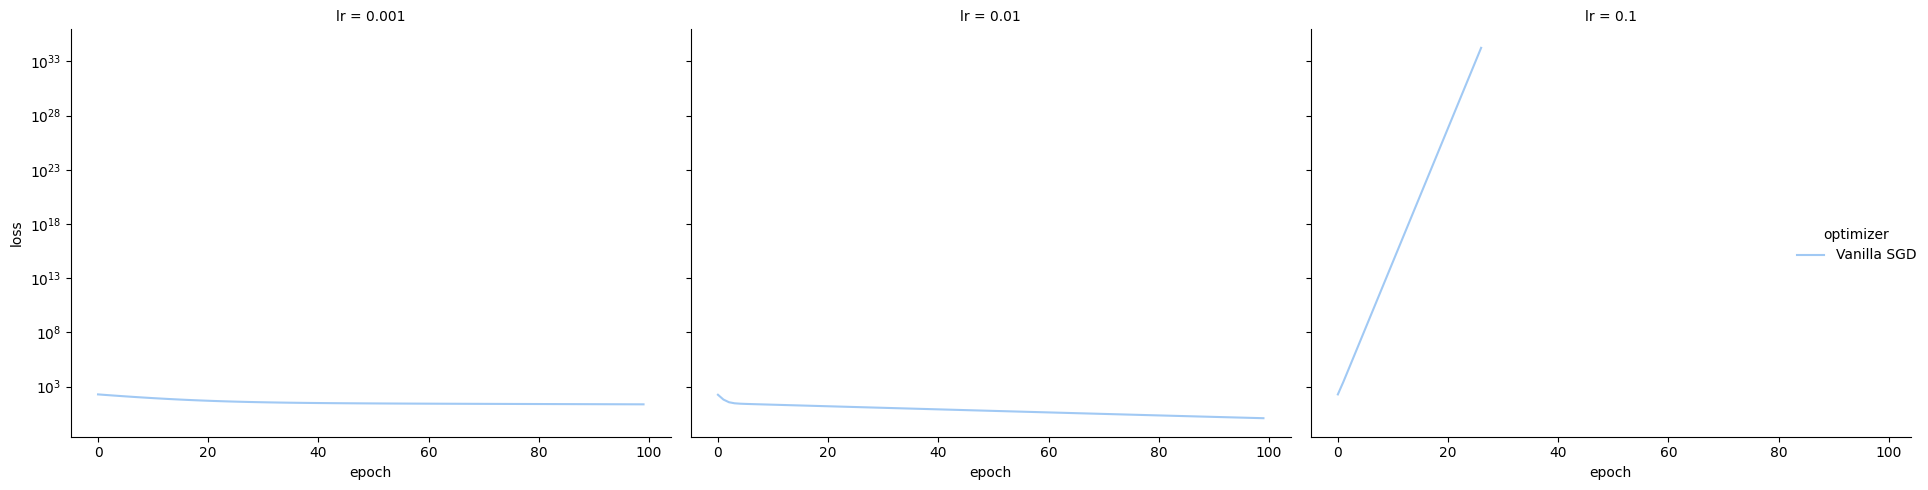

In [33]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df,
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

# Map the lineplot to each subplot
grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='loss',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Add titles and adjust the layout
grid.set_axis_labels('epoch', 'loss')
grid.set_titles(col_template="lr = {col_name}")
grid.add_legend(title='optimizer')

# Set log scale for y-axis on all subplots
for ax in grid.axes.flat:
    ax.set_yscale('log')

plt.tight_layout()
plt.show()
